In [ ]:
# Load libraries
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np
from sklearn.metrics import confusion_matrix


In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
import numpy as np
import pandas as pd

In [ ]:
train_x = pd.read_csv('./airbnb_train_x.csv', on_bad_lines='skip', engine='python')
train_y = pd.read_csv('./airbnb_train_y.csv', on_bad_lines='skip')
test_x = pd.read_csv('./airbnb_test_x.csv', on_bad_lines='skip')

In [ ]:
# Join the training y to the training x file
# Also turn the target variables into categorical
train = pd.concat([train_x, train_y], axis=1)
train['perfect_rating_score'] = train['perfect_rating_score'].astype('category')
#train['high_booking_rate'] = train['high_booking_rate'].astype('category')

print(train.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92067 entries, 0 to 92066
Data columns (total 63 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   name                       92048 non-null  object  
 1   summary                    88816 non-null  object  
 2   space                      72442 non-null  object  
 3   description                92048 non-null  object  
 4   experiences_offered        92067 non-null  object  
 5   neighborhood_overview      62428 non-null  object  
 6   notes                      45747 non-null  object  
 7   transit                    64335 non-null  object  
 8   access                     58404 non-null  object  
 9   interaction                56661 non-null  object  
 10  house_rules                64234 non-null  object  
 11  host_name                  91898 non-null  object  
 12  host_since                 91898 non-null  object  
 13  host_location              9165

In [ ]:
text_cols = ['summary', 'description', 'house_rules', 'host_about']
for col in text_cols:
    train[f'{col}_len'] = train[col].fillna('').apply(len)
    train[f'{col}_word_count'] = train[col].fillna('').apply(lambda x: len(x.split()))


In [ ]:
text_col = ['summary', 'description', 'house_rules', 'host_about']
for col in text_cols:
    test_x['{col}_len'] = train[col].fillna('').apply(len)
    test_x[f'{col}_word_count'] = train[col].fillna('').apply(lambda x: len(x.split()))


In [ ]:
# Host bio present
train['host_bio_provided'] = train['host_about'].notna().astype(int)

# Host response rate
train['host_response_rate'] = train['host_response_rate'].fillna(0)

# Host experience in years
train['host_since'] = pd.to_datetime(train['host_since'], errors='coerce')
train['host_years'] = 2025 - train['host_since'].dt.year.fillna(2025)

# Total listings
train['host_listings_count'] = train['host_listings_count'].fillna(0)
train['host_total_listings_count'] = train['host_total_listings_count'].fillna(0)


In [ ]:
# Host bio present
test_x['host_bio_provided'] = test_x['host_about'].notna().astype(int)

# Host response rate
test_x['host_response_rate'] = test_x['host_response_rate'].fillna(0)

# Host experience in years
test_x['host_since'] = pd.to_datetime(test_x['host_since'], errors='coerce')
test_x['host_years'] = 2025 - test_x['host_since'].dt.year.fillna(2025)

# Total listings
test_x['host_listings_count'] = test_x['host_listings_count'].fillna(0)
test_x['host_total_listings_count'] = test_x['host_total_listings_count'].fillna(0)

In [ ]:
# Latitude & longitude directly usable
# Create geo-cluster (optional)
from sklearn.cluster import KMeans
coords = train[['latitude', 'longitude']].dropna()
kmeans = KMeans(n_clusters=10, random_state=42).fit(coords)
train.loc[coords.index, 'geo_cluster'] = kmeans.labels_

# Avg rating by city (if perfect_rating_binary exists)
if 'perfect_rating_binary' in train.columns:
    city_rating = train.groupby('city')['perfect_rating_binary'].mean()
    train['city_avg_rating'] = train['city'].map(city_rating)


In [ ]:
# Latitude & longitude directly usable
# Create geo-cluster (optional)
from sklearn.cluster import KMeans
coords = test_x[['latitude', 'longitude']].dropna()
kmeans = KMeans(n_clusters=10, random_state=42).fit(coords)
test_x.loc[coords.index, 'geo_cluster'] = kmeans.labels_

# Avg rating by city (if perfect_rating_binary exists)
if 'perfect_rating_binary' in test_x.columns:
    city_rating = test_x.groupby('city')['perfect_rating_binary'].mean()
    test_x['city_avg_rating'] = test_x['city'].map(city_rating)


In [ ]:
# Combined room quality
train['room_score'] = 0.6 * train['bedrooms'].fillna(0) + 0.4 * train['bathrooms'].fillna(0)

# Beds per guest
train['beds_per_guest'] = train['beds'].fillna(1) / train['accommodates'].replace(0, 1)


In [ ]:
# Combined room quality
test_x['room_score'] = 0.6 * test_x['bedrooms'].fillna(0) + 0.4 * test_x['bathrooms'].fillna(0)

# Beds per guest
test_x['beds_per_guest'] = test_x['beds'].fillna(1) / test_x['accommodates'].replace(0, 1)

In [ ]:
train['logprice'] = np.log(train['price'].replace(0, np.nan)).fillna(0)

# Price per guest
train['price_per_guest'] = train['price'] / train['guests_included'].replace(0, 1)

# Weekly/Monthly discount
train['weekly_discount_ratio'] = train['weekly_price'] / (train['price'] * 7)
train['monthly_discount_ratio'] = train['monthly_price'] / (train['price'] * 30)
train['weekly_discount_ratio'] = train['weekly_discount_ratio'].replace([np.inf, -np.inf], np.nan).fillna(1.0)
train['monthly_discount_ratio'] = train['monthly_discount_ratio'].replace([np.inf, -np.inf], np.nan).fillna(1.0)


In [ ]:
test_x['logprice'] = np.log(test_x['price'].replace(0, np.nan)).fillna(0)

# Price per guest
test_x['price_per_guest'] = test_x['price'] / test_x['guests_included'].replace(0, 1)

# Weekly/Monthly discount
test_x['weekly_discount_ratio'] = test_x['weekly_price'] / (test_x['price'] * 7)
test_x['monthly_discount_ratio'] = train['monthly_price'] / (test_x['price'] * 30)
test_x['weekly_discount_ratio'] = test_x['weekly_discount_ratio'].replace([np.inf, -np.inf], np.nan).fillna(1.0)
test_x['monthly_discount_ratio'] = test_x['monthly_discount_ratio'].replace([np.inf, -np.inf], np.nan).fillna(1.0)

In [ ]:
train['availability_ratio'] = (
    train[['availability_30', 'availability_60', 'availability_90', 'availability_365']].sum(axis=1) / (30 + 60 + 90 + 365)
)


In [ ]:
test_x['availability_ratio'] = (
    test_x[['availability_30', 'availability_60', 'availability_90', 'availability_365']].sum(axis=1) / (30 + 60 + 90 + 365)
)

In [ ]:
# Cancellation policy (ordinal)
cancel_map = {'flexible': 0, 'moderate': 1, 'strict': 2}
train['cancellation_encoded'] = train['cancellation_policy'].map(cancel_map).fillna(1)

# Room type one-hot
room_dummies = pd.get_dummies(train['room_type'], prefix='room', drop_first=True)
train = pd.concat([train, room_dummies], axis=1)


In [ ]:
# Cancellation policy (ordinal)
cancel_map = {'flexible': 0, 'moderate': 1, 'strict': 2}
test_x['cancellation_encoded'] = test_x['cancellation_policy'].map(cancel_map).fillna(1)

# Room type one-hot
room_dummies = pd.get_dummies(test_x['room_type'], prefix='room', drop_first=True)
test_x = pd.concat([test_x, room_dummies], axis=1)


In [ ]:
# Days since first review (proxy for popularity)
train['first_review'] = pd.to_datetime(train['first_review'], errors='coerce')
train['days_since_first_review'] = (pd.Timestamp('2025-01-01') - train['first_review']).dt.days.fillna(9999)

# License presence
train['has_license'] = train['license'].notna().astype(int)


In [ ]:
# Days since first review (proxy for popularity)
test_x['first_review'] = pd.to_datetime(test_x['first_review'], errors='coerce')
test_x['days_since_first_review'] = (pd.Timestamp('2025-01-01') - test_x['first_review']).dt.days.fillna(9999)

# License presence
test_x['has_license'] = test_x['license'].notna().astype(int)


In [ ]:
# Optional: filter final features (numerical only)
model_ready = train.select_dtypes(include=['float64', 'int64']).fillna(0)


In [ ]:
from sklearn.cluster import KMeans

# Select latitude and longitude
coords = model_ready[['latitude', 'longitude']]

# Set number of clusters (tune based on your city's geography)
kmeans = KMeans(n_clusters=10, random_state=42)

# Fit and assign cluster labels
model_ready['geo_cluster'] = kmeans.fit_predict(coords)


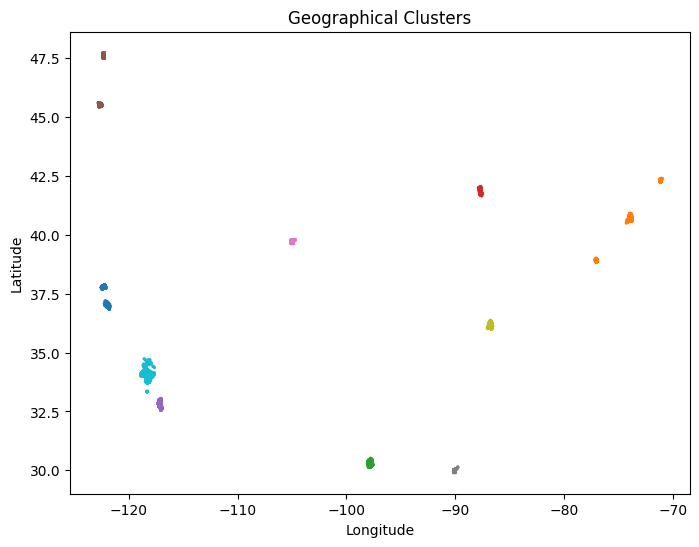

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(model_ready['longitude'], model_ready['latitude'], c=model_ready['geo_cluster'], cmap='tab10', s=2)
plt.title("Geographical Clusters")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


In [ ]:
train.head()

,name,summary,space,description,experiences_offered,neighborhood_overview,notes,transit,access,interaction,...,logprice,price_per_guest,weekly_discount_ratio,monthly_discount_ratio,availability_ratio,cancellation_encoded,room_Private room,room_Shared room,days_since_first_review,has_license
0,Perfect Apt Steps From Central Park,"Central Park Apt! 2 bedroom 1 bath, a block aw...","2 bedroom 1 bath, a block away from train, 1 b...","Central Park Apt! 2 bedroom 1 bath, a block aw...",none,Central Park North is the north side of Centra...,NaN,The apartment is just a block away from the 2/...,You'll have access to the common areas: living...,I'll be available via text throughout your sta...,...,4.248495,70.0,1.0,1.0,0.363303,2.0,True,False,2962,0
1,2 bedroom Bernal Heights Condo - FABULOUS views!,"An entire lovely, comfortable, quiet and relax...","My condo is a light -filled two bedroom, one b...","An entire lovely, comfortable, quiet and relax...",none,Bernal Heights is like a village. It has been...,This condo is located on a hill and is on the ...,I will be happy to provide you with my Uber an...,As guests who are renting my entire condo whil...,I can be reached anytime by calling or texting...,...,5.521461,125.0,1.0,1.0,0.000000,2.0,False,False,4839,0
2,Zen in the Heart of Brooklyn,"Sunny room in cozy apartment close to JFK, LGA...",The apartment is located in the heart of Bushw...,"Sunny room in cozy apartment close to JFK, LGA...",none,Bushwick is an extremely hot neighborhood righ...,NaN,Our location is extremely convenient to get al...,"You will have access to the bedroom, living ro...",I have been living in this neighborhood for 4 ...,...,4.605170,100.0,1.0,1.0,1.000000,2.0,True,False,3368,0
3,any term sublet night week months,NaN,hi love to host u the apt loceded in the uppe...,hi love to host u the apt loceded in the uppe...,none,NaN,NaN,NaN,NaN,NaN,...,5.220356,92.5,1.0,1.0,0.814679,2.0,False,False,5379,0
4,Cozy and Small bedroom in Astoria!!,"Small bedroom but comfy in Astoria, close to t...",NaN,"Small bedroom but comfy in Astoria, close to t...",none,"Astoria is a great area. Lots of bar, restaura...",NaN,NaN,NaN,NaN,...,3.555348,35.0,1.0,1.0,0.034862,0.0,True,False,3257,0


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92067 entries, 0 to 92066
Data columns (total 86 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   name                       74501 non-null  object        
 1   summary                    71905 non-null  object        
 2   space                      58558 non-null  object        
 3   description                74502 non-null  object        
 4   experiences_offered        74515 non-null  object        
 5   neighborhood_overview      50482 non-null  object        
 6   notes                      37026 non-null  object        
 7   transit                    52102 non-null  object        
 8   access                     47302 non-null  object        
 9   interaction                45934 non-null  object        
 10  house_rules                52009 non-null  object        
 11  host_name                  74380 non-null  object        
 12  host

In [ ]:
amenities= pd.read_csv('./amenities_included.csv')

In [ ]:
selected_columns = ['has_wifi'	, 'has_kitchen',	'has_ac'	,'has_heating',	'has_parking',	'has_tv',	'pet_friendly',	'has_essentials'	,'has_safety_features'	,'has_washer_dryer',	'amenity_score' ]  # example subset

# Concatenate just those columns with train
train_with_selected_amenities = pd.concat([
    train.reset_index(drop=True),
    amenities[selected_columns].reset_index(drop=True)
], axis=1)

In [ ]:
train_with_selected_amenities.head()

,name,summary,space,description,experiences_offered,neighborhood_overview,notes,transit,access,interaction,...,has_kitchen,has_ac,has_heating,has_parking,has_tv,pet_friendly,has_essentials,has_safety_features,has_washer_dryer,amenity_score
0,Perfect Apt Steps From Central Park,"Central Park Apt! 2 bedroom 1 bath, a block aw...","2 bedroom 1 bath, a block away from train, 1 b...","Central Park Apt! 2 bedroom 1 bath, a block aw...",none,Central Park North is the north side of Centra...,NaN,The apartment is just a block away from the 2/...,You'll have access to the common areas: living...,I'll be available via text throughout your sta...,...,1,1,1,0,1,0,1,1,0,0.7
1,2 bedroom Bernal Heights Condo - FABULOUS views!,"An entire lovely, comfortable, quiet and relax...","My condo is a light -filled two bedroom, one b...","An entire lovely, comfortable, quiet and relax...",none,Bernal Heights is like a village. It has been...,This condo is located on a hill and is on the ...,I will be happy to provide you with my Uber an...,As guests who are renting my entire condo whil...,I can be reached anytime by calling or texting...,...,1,0,1,0,1,0,1,1,0,0.6
2,Zen in the Heart of Brooklyn,"Sunny room in cozy apartment close to JFK, LGA...",The apartment is located in the heart of Bushw...,"Sunny room in cozy apartment close to JFK, LGA...",none,Bushwick is an extremely hot neighborhood righ...,NaN,Our location is extremely convenient to get al...,"You will have access to the bedroom, living ro...",I have been living in this neighborhood for 4 ...,...,1,1,1,1,1,1,1,0,1,0.9
3,any term sublet night week months,NaN,hi love to host u the apt loceded in the uppe...,hi love to host u the apt loceded in the uppe...,none,NaN,NaN,NaN,NaN,NaN,...,1,1,1,1,1,1,0,0,0,0.7
4,Cozy and Small bedroom in Astoria!!,"Small bedroom but comfy in Astoria, close to t...",NaN,"Small bedroom but comfy in Astoria, close to t...",none,"Astoria is a great area. Lots of bar, restaura...",NaN,NaN,NaN,NaN,...,1,1,1,0,1,1,0,1,0,0.7


In [ ]:
tf = train_with_selected_amenities.copy()

In [ ]:
tf.head()

,name,summary,space,description,experiences_offered,neighborhood_overview,notes,transit,access,interaction,...,has_kitchen,has_ac,has_heating,has_parking,has_tv,pet_friendly,has_essentials,has_safety_features,has_washer_dryer,amenity_score
0,Perfect Apt Steps From Central Park,"Central Park Apt! 2 bedroom 1 bath, a block aw...","2 bedroom 1 bath, a block away from train, 1 b...","Central Park Apt! 2 bedroom 1 bath, a block aw...",none,Central Park North is the north side of Centra...,NaN,The apartment is just a block away from the 2/...,You'll have access to the common areas: living...,I'll be available via text throughout your sta...,...,1,1,1,0,1,0,1,1,0,0.7
1,2 bedroom Bernal Heights Condo - FABULOUS views!,"An entire lovely, comfortable, quiet and relax...","My condo is a light -filled two bedroom, one b...","An entire lovely, comfortable, quiet and relax...",none,Bernal Heights is like a village. It has been...,This condo is located on a hill and is on the ...,I will be happy to provide you with my Uber an...,As guests who are renting my entire condo whil...,I can be reached anytime by calling or texting...,...,1,0,1,0,1,0,1,1,0,0.6
2,Zen in the Heart of Brooklyn,"Sunny room in cozy apartment close to JFK, LGA...",The apartment is located in the heart of Bushw...,"Sunny room in cozy apartment close to JFK, LGA...",none,Bushwick is an extremely hot neighborhood righ...,NaN,Our location is extremely convenient to get al...,"You will have access to the bedroom, living ro...",I have been living in this neighborhood for 4 ...,...,1,1,1,1,1,1,1,0,1,0.9
3,any term sublet night week months,NaN,hi love to host u the apt loceded in the uppe...,hi love to host u the apt loceded in the uppe...,none,NaN,NaN,NaN,NaN,NaN,...,1,1,1,1,1,1,0,0,0,0.7
4,Cozy and Small bedroom in Astoria!!,"Small bedroom but comfy in Astoria, close to t...",NaN,"Small bedroom but comfy in Astoria, close to t...",none,"Astoria is a great area. Lots of bar, restaura...",NaN,NaN,NaN,NaN,...,1,1,1,0,1,1,0,1,0,0.7


In [ ]:


selector = VarianceThreshold(threshold=0.01)
X_filtered = selector.fit_transform(tf[model_ready.columns])

In [ ]:
# Convert to binary numeric format
tf['perfect_rating_binary'] = tf['perfect_rating_score'].map({'YES': 1, 'NO': 0})

In [ ]:
model_ready.head()

,host_response_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,square_feet,...,room_score,beds_per_guest,logprice,price_per_guest,weekly_discount_ratio,monthly_discount_ratio,availability_ratio,cancellation_encoded,days_since_first_review,has_license
0,100.0,2.0,2.0,40.801020,-73.954007,2.0,1.0,2.0,1.0,0.0,...,1.6,0.500000,4.248495,70.0,1.0,1.0,0.363303,2.0,2962.0,0
1,100.0,2.0,2.0,37.745306,-122.411218,4.0,1.0,2.0,2.0,0.0,...,1.6,0.500000,5.521461,125.0,1.0,1.0,0.000000,2.0,4839.0,0
2,0.0,2.0,2.0,40.701036,-73.918769,2.0,1.0,1.0,1.0,0.0,...,1.0,0.500000,4.605170,100.0,1.0,1.0,1.000000,2.0,3368.0,0
3,100.0,2.0,2.0,40.771044,-73.956285,6.0,1.0,1.0,1.0,0.0,...,1.0,0.166667,5.220356,92.5,1.0,1.0,0.814679,2.0,5379.0,0
4,0.0,1.0,1.0,40.760605,-73.917666,1.0,1.0,1.0,1.0,0.0,...,1.0,1.000000,3.555348,35.0,1.0,1.0,0.034862,0.0,3257.0,0


In [ ]:

X = model_ready.drop(columns=['perfect_rating_binary'], errors='ignore')
y = tf['perfect_rating_binary'].astype(int)

lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=0.01, random_state=42))
])

lasso_pipeline.fit(X, y)
coefs = pd.Series(lasso_pipeline.named_steps['lasso'].coef_, index=X.columns)
selected = coefs[coefs != 0].sort_values(ascending=False)

print("✅ Best Features by Lasso:\n", selected)

✅ Best Features by Lasso:
 price_per_guest            0.031500
host_years                 0.014065
bathrooms                  0.008316
room_score                 0.008255
price                      0.008141
cleaning_fee               0.002596
beds                      -0.000433
weekly_price              -0.000448
longitude                 -0.002906
accommodates              -0.005265
description_word_count    -0.006106
latitude                  -0.008000
house_rules_word_count    -0.015990
availability_365          -0.016426
cancellation_encoded      -0.025861
host_response_rate        -0.050583
days_since_first_review   -0.111844
dtype: float64


# 1st XG Boost

In [ ]:

# Split your data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize XGBoost classifier with tuned hyperparameters
xgb_model = xgb.XGBClassifier(
    random_state=42,
    max_depth=4,
    min_child_weight=3,
    gamma=0.2,
    subsample=0.8,
    colsample_bytree=0.8,
    learning_rate=0.05,
    n_estimators=300,
    reg_alpha=0.5,
    reg_lambda=1.0,
    use_label_encoder=False,
    eval_metric="logloss"
)

# Train the model
xgb_model.fit(X_train, y_train)

# Predict probabilities for the positive class
y_probs = xgb_model.predict_proba(X_test)[:, 1]

# Apply custom threshold
threshold = 0.49
y_pred = (y_probs >= threshold).astype(int)

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
tpr = tp / (tp + fn)
fpr = fp / (fp + tn)

print(f"Accuracy of XGBoost with threshold {threshold}: {accuracy:.4f}")
print(f"True Positive Rate (TPR): {tpr:.4f}")
print(f"False Positive Rate (FPR): {fpr:.4f}")

Accuracy of XGBoost with threshold 0.49: 0.7691
True Positive Rate (TPR): 0.4335
False Positive Rate (FPR): 0.0956


Best Threshold (Youden's J): 0.2734
AUC: 0.8056


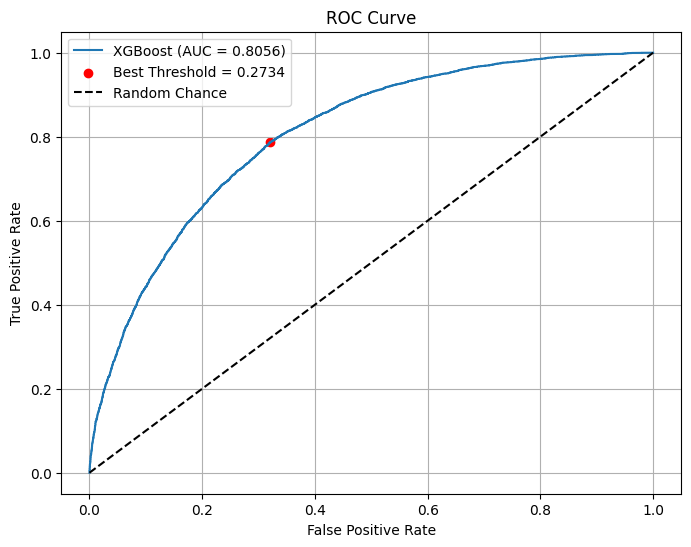

In [ ]:

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = roc_auc_score(y_test, y_probs)

# Find the best threshold using Youden's J statistic
j_scores = tpr - fpr
best_index = j_scores.argmax()
best_threshold = thresholds[best_index]

print(f"Best Threshold (Youden's J): {best_threshold:.4f}")
print(f"AUC: {roc_auc:.4f}")

# Plot ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {roc_auc:.4f})")
plt.scatter(fpr[best_index], tpr[best_index], color='red', label=f"Best Threshold = {best_threshold:.4f}")
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:


# Thresholds from 0.4 to 0.6 with step size 0.01
thresholds = np.arange(0.4, 0.61, 0.01)

# Store results
results = []

print(f"{'Threshold':>10} {'TPR':>10} {'FPR':>10}")
print("-" * 35)

for threshold in thresholds:
    y_pred = (y_probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    results.append((threshold, tpr, fpr))
    print(f"{threshold:10.2f} {tpr:10.4f} {fpr:10.4f}")


 Threshold        TPR        FPR
-----------------------------------
      0.40     0.5953     0.1743
      0.41     0.5771     0.1644
      0.42     0.5571     0.1551
      0.43     0.5384     0.1455
      0.44     0.5233     0.1371
      0.45     0.5040     0.1280
      0.46     0.4837     0.1190
      0.47     0.4682     0.1106
      0.48     0.4503     0.1032
      0.49     0.4335     0.0956
      0.50     0.4168     0.0885
      0.51     0.3964     0.0825
      0.52     0.3828     0.0772
      0.53     0.3665     0.0720
      0.54     0.3503     0.0664
      0.55     0.3344     0.0607
      0.56     0.3164     0.0566
      0.57     0.3002     0.0531
      0.58     0.2860     0.0488
      0.59     0.2707     0.0452
      0.60     0.2560     0.0407


# Xg Boost Loop 2

In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve
from itertools import product

# Replace with your actual data
# X = ...
# y = ...

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Hyperparameter options
max_depth_list = [3, 4]
min_child_weight_list = [1, 3]
gamma_list = [0.1, 0.2]
subsample_list = [0.8]
colsample_bytree_list = [0.8]
learning_rate_list = [0.05]
reg_alpha_list = [0.5]
reg_lambda_list = [1.0]
n_estimators_list = [300]

# All combinations
combinations = list(product(
    max_depth_list, min_child_weight_list, gamma_list,
    subsample_list, colsample_bytree_list, learning_rate_list,
    reg_alpha_list, reg_lambda_list, n_estimators_list
))

print(f"\n🔁 Total combinations to evaluate: {len(combinations)}\n")

# For storing all results
results = []

# Loop through combinations
for i, (max_depth, min_child_weight, gamma, subsample,
        colsample_bytree, learning_rate, reg_alpha, reg_lambda, n_estimators) in enumerate(combinations, 1):

    print(f"➡️ Combo {i}: max_depth={max_depth}, min_child_weight={min_child_weight}, gamma={gamma}")

    xgb_model = xgb.XGBClassifier(
        random_state=42,
        max_depth=max_depth,
        min_child_weight=min_child_weight,
        gamma=gamma,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        learning_rate=learning_rate,
        n_estimators=n_estimators,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        use_label_encoder=False,
        eval_metric="logloss"
    )

    xgb_model.fit(X_train, y_train)
    y_probs = xgb_model.predict_proba(X_test)[:, 1]

    # ROC and thresholds
    fpr_list, tpr_list, thresholds = roc_curve(y_test, y_probs)
    valid_indices = np.where(fpr_list <= 0.10)[0]

    if valid_indices.size > 0:
        best_idx = valid_indices[np.argmax(tpr_list[valid_indices])]
        best_threshold = thresholds[best_idx]
        best_tpr = tpr_list[best_idx]
        best_fpr = fpr_list[best_idx]

        y_pred = (y_probs >= best_threshold).astype(int)
        acc = accuracy_score(y_test, y_pred)

        print(f"   ✅ TPR: {best_tpr:.3f}, FPR: {best_fpr:.3f}, Threshold: {best_threshold:.3f}, Acc: {acc:.3f}")
    else:
        best_threshold = None
        best_tpr = None
        best_fpr = None
        acc = None
        print("   ❌ No threshold with FPR ≤ 0.10")

    # Save result
    results.append({
        "Combo": i,
        "max_depth": max_depth,
        "min_child_weight": min_child_weight,
        "gamma": gamma,
        "subsample": subsample,
        "colsample_bytree": colsample_bytree,
        "learning_rate": learning_rate,
        "reg_alpha": reg_alpha,
        "reg_lambda": reg_lambda,
        "n_estimators": n_estimators,
        "Best_Threshold": best_threshold,
        "TPR": best_tpr,
        "FPR": best_fpr,
        "Accuracy": acc
    })

    print("-" * 70)

# Final DataFrame
df_results = pd.DataFrame(results)
import ace_tools as tools; tools.display_dataframe_to_user(name="XGBoost Hyperparameter Search Results", dataframe=df_results)



🔁 Total combinations to evaluate: 8

➡️ Combo 1: max_depth=3, min_child_weight=1, gamma=0.1
   ✅ TPR: 0.381, FPR: 0.100, Threshold: 0.450, Acc: 0.751
----------------------------------------------------------------------
➡️ Combo 2: max_depth=3, min_child_weight=1, gamma=0.2
   ✅ TPR: 0.381, FPR: 0.100, Threshold: 0.450, Acc: 0.751
----------------------------------------------------------------------
➡️ Combo 3: max_depth=3, min_child_weight=3, gamma=0.1
   ✅ TPR: 0.382, FPR: 0.100, Threshold: 0.449, Acc: 0.751
----------------------------------------------------------------------
➡️ Combo 4: max_depth=3, min_child_weight=3, gamma=0.2
   ✅ TPR: 0.382, FPR: 0.100, Threshold: 0.449, Acc: 0.751
----------------------------------------------------------------------
➡️ Combo 5: max_depth=4, min_child_weight=1, gamma=0.1
   ✅ TPR: 0.393, FPR: 0.100, Threshold: 0.455, Acc: 0.755
----------------------------------------------------------------------
➡️ Combo 6: max_depth=4, min_child_weight=

ModuleNotFoundError: No module named 'ace_tools'

# Big Boy

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans



# --- GEO CLUSTERING ---
coords = train[['latitude', 'longitude']]
kmeans = KMeans(n_clusters=10, random_state=42)
train['geo_cluster'] = kmeans.fit_predict(coords)

# --- DISCOUNTED PRICE RATIO ---
train['discounted_price_ratio'] = 1 - (train['weekly_price'] / (7 * train['price']))
train['discounted_price_ratio'] = train['discounted_price_ratio'].replace([float('inf'), -float('inf')], pd.NA)
train['discounted_price_ratio'] = train['discounted_price_ratio'].fillna(0)

# --- FINAL DATASET ---
model_ready = train.copy()


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
import pandas as pd

# Keep only numeric columns
X = model_ready.drop(columns=['perfect_rating_binary'], errors='ignore')
X = X.select_dtypes(include=['number'])

# Ensure 'tf' is defined or use model_ready
y = model_ready['perfect_rating_binary'].astype(int)  # Replacing 'tf' with model_ready

# Lasso pipeline
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=0.01, random_state=42))
])

lasso_pipeline.fit(X, y)

# Get non-zero coefficients
coefs = pd.Series(lasso_pipeline.named_steps['lasso'].coef_, index=X.columns)
selected = coefs[coefs != 0].sort_values(ascending=False)

print("✅ Best Features by Lasso:\n", selected)


XGBOOST NEW

In [ ]:

# Split your data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize XGBoost classifier with tuned hyperparameters
xgb_model = xgb.XGBClassifier(
    random_state=42,
    max_depth=4,
    min_child_weight=3,
    gamma=0.2,
    subsample=0.8,
    colsample_bytree=0.8,
    learning_rate=0.05,
    n_estimators=300,
    reg_alpha=0.5,
    reg_lambda=1.0,
    use_label_encoder=False,
    eval_metric="logloss"
)

# Train the model
xgb_model.fit(X_train, y_train)

# Predict probabilities for the positive class
y_probs = xgb_model.predict_proba(X_test)[:, 1]

# Apply custom threshold
threshold = 0.49
y_pred = (y_probs >= threshold).astype(int)

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
tpr = tp / (tp + fn)
fpr = fp / (fp + tn)

print(f"Accuracy of XGBoost with threshold {threshold}: {accuracy:.4f}")
print(f"True Positive Rate (TPR): {tpr:.4f}")
print(f"False Positive Rate (FPR): {fpr:.4f}")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve
from itertools import product
import time
import os

# 🔧 REPLACE with your actual dataset
# X = ...
# y = ...

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Hyperparameter grid
max_depth_list = [3, 4, 5, 6]
min_child_weight_list = [1, 3, 5]
gamma_list = [0, 0.1, 0.2, 0.3]
subsample_list = [0.6, 0.8, 1.0]
colsample_bytree_list = [0.6, 0.8, 1.0]
learning_rate_list = [0.01, 0.05, 0.1]
reg_alpha_list = [0, 0.5, 1.0]
reg_lambda_list = [0.5, 1.0, 1.5]
n_estimators_list = [100, 200, 300]

# All combinations
combinations = list(product(
    max_depth_list, min_child_weight_list, gamma_list,
    subsample_list, colsample_bytree_list, learning_rate_list,
    reg_alpha_list, reg_lambda_list, n_estimators_list
))

# Prepare save path
SAVE_EVERY = 100
results = []
checkpoint_path = "https://drive.google.com/drive/folders/1r5BSC0_KBVDhNYVEuwRv8w9IdnIjsXl5?usp=drive_link"  # adjust if needed

print(f"🔁 Total combinations to try: {len(combinations)}")
start_time = time.time()

# Main loop
for i, (max_depth, min_child_weight, gamma, subsample,
        colsample_bytree, learning_rate, reg_alpha, reg_lambda, n_estimators) in enumerate(combinations, 1):

    print(f"➡️ Combo {i}: max_depth={max_depth}, gamma={gamma}, learning_rate={learning_rate}")

    try:
        # Train model
        model = xgb.XGBClassifier(
            random_state=42,
            max_depth=max_depth,
            min_child_weight=min_child_weight,
            gamma=gamma,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            learning_rate=learning_rate,
            n_estimators=n_estimators,
            reg_alpha=reg_alpha,
            reg_lambda=reg_lambda,
            use_label_encoder=False,
            eval_metric="logloss"
        )
        model.fit(X_train, y_train)
        y_probs = model.predict_proba(X_test)[:, 1]

        # ROC curve
        fpr, tpr, thresholds = roc_curve(y_test, y_probs)
        valid_indices = np.where(fpr <= 0.10)[0]

        if valid_indices.size > 0:
            best_idx = valid_indices[np.argmax(tpr[valid_indices])]
            best_threshold = thresholds[best_idx]
            best_tpr = tpr[best_idx]
            best_fpr = fpr[best_idx]
            y_pred = (y_probs >= best_threshold).astype(int)
            acc = accuracy_score(y_test, y_pred)
        else:
            best_threshold = None
            best_tpr = None
            best_fpr = None
            acc = None

        # Save result
        results.append({
            "Combo": i,
            "max_depth": max_depth,
            "min_child_weight": min_child_weight,
            "gamma": gamma,
            "subsample": subsample,
            "colsample_bytree": colsample_bytree,
            "learning_rate": learning_rate,
            "reg_alpha": reg_alpha,
            "reg_lambda": reg_lambda,
            "n_estimators": n_estimators,
            "Best_Threshold": best_threshold,
            "TPR": best_tpr,
            "FPR": best_fpr,
            "Accuracy": acc
        })

        print(f"   ✅ TPR: {best_tpr:.3f}, FPR: {best_fpr:.3f}, Acc: {acc:.3f}  ✅")

    except Exception as e:
        print(f"   ❌ Error at combo {i}: {e}")

    # Auto-save checkpoint
    if i % SAVE_EVERY == 0 or i == len(combinations):
        df_results = pd.DataFrame(results)
        df_results.to_csv(checkpoint_path, index=False)
        print(f"💾 Auto-saved at combo {i} to: {checkpoint_path}")

    print("-" * 70)

# Final message
total_time = time.time() - start_time
print(f"\n✅ All combinations complete in {total_time/60:.2f} minutes.")


Streaming output truncated to the last 5000 lines.
   ✅ TPR: 0.432, FPR: 0.100, Acc: 0.766  ✅
----------------------------------------------------------------------
➡️ Combo 387: max_depth=3, gamma=0, learning_rate=0.1
   ✅ TPR: 0.439, FPR: 0.100, Acc: 0.768  ✅
----------------------------------------------------------------------
➡️ Combo 388: max_depth=3, gamma=0, learning_rate=0.1
   ✅ TPR: 0.413, FPR: 0.100, Acc: 0.760  ✅
----------------------------------------------------------------------
➡️ Combo 389: max_depth=3, gamma=0, learning_rate=0.1
   ✅ TPR: 0.433, FPR: 0.100, Acc: 0.766  ✅
----------------------------------------------------------------------
➡️ Combo 390: max_depth=3, gamma=0, learning_rate=0.1
   ✅ TPR: 0.441, FPR: 0.100, Acc: 0.768  ✅
----------------------------------------------------------------------
➡️ Combo 391: max_depth=3, gamma=0, learning_rate=0.1
   ✅ TPR: 0.421, FPR: 0.100, Acc: 0.762  ✅
------------------------------------------------------------------

KeyboardInterrupt: 

In [ ]:
# Predict probabilities on test_x
test_probs = xgb_model.predict_proba(test_x)[:, 1]

# Set your threshold
threshold = 0.5  # or use the best threshold found earlier

# Generate binary predictions
test_pred_binary = (test_probs >= threshold).astype(int)

# Convert to "yes"/"no"
test_pred_labels = np.where(test_pred_binary == 1, "yes", "no")

# If you want to create a DataFrame
import pandas as pd
test_predictions_df = pd.DataFrame({'prediction': test_pred_labels})

# Preview
print(test_predictions_df.head())


In [ ]:
# Merge preprocessing steps (apply on both train and test data!)
def preprocess(df):
    df = df.copy()

    # Drop unneeded columns
    cols_to_drop = ['name', 'summary', 'space', 'description', 'experiences_offered',
                    'neighborhood_overview', 'notes', 'transit', 'access', 'interaction',
                    'house_rules', 'host_name', 'host_about', 'street', 'features',
                    'host_location', 'first_review', 'license', 'jurisdiction_names']
    df = df.drop(columns=[col for col in cols_to_drop if col in df.columns], errors='ignore')

    # Convert date columns to numeric (e.g., number of days since listing)
    if 'host_since' in df.columns:
        df['host_since'] = pd.to_datetime(df['host_since'], errors='coerce')
        df['host_since_days'] = (pd.Timestamp('today') - df['host_since']).dt.days
        df.drop(columns='host_since', inplace=True)

    # One-hot encode remaining categorical features
    df = pd.get_dummies(df, drop_first=True)

    return df


In [ ]:
# Apply preprocessing
X_train_preprocessed = preprocess(X_train)
X_test_preprocessed = preprocess(test_x)

# Align test columns to train
X_test_preprocessed = X_test_preprocessed.reindex(columns=X_train_preprocessed.columns, fill_value=0)


In [ ]:
test_probs = xgb_model.predict_proba(X_test_preprocessed)[:, 1]
test_pred_binary = (test_probs >= threshold).astype(int)
test_pred_labels = np.where(test_pred_binary == 1, "yes", "no")


In [ ]:


# Assuming test_pred_labels is your array of "yes"/"no" values
test_pred_series = pd.Series(test_pred_labels, name="prediction")


In [ ]:
# Optional: set index if needed, otherwise this uses default 0,1,2,...
test_pred_series.index = test_x.index  # Only do this if test_x was already loaded


In [ ]:
test_pred_series.info()

In [ ]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
X_filtered = selector.fit_transform(train[model_ready.columns])


In [ ]:
# Convert to binary numeric format
train['perfect_rating_binary'] = train['perfect_rating_score'].map({'YES': 1, 'NO': 0})


In [ ]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import pandas as pd

X = model_ready.drop(columns=['perfect_rating_binary'], errors='ignore')
y = train['perfect_rating_binary'].astype(int)

lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=0.01, random_state=42))
])

lasso_pipeline.fit(X, y)
coefs = pd.Series(lasso_pipeline.named_steps['lasso'].coef_, index=X.columns)
selected = coefs[coefs != 0].sort_values(ascending=False)

print("✅ Best Features by Lasso:\n", selected)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

print("✅ Best Features by Random Forest:\n", importances.head(15))


In [ ]:
# from sklearn.feature_selection import RFE
# from sklearn.linear_model import LogisticRegression

# model = LogisticRegression(max_iter=1000)
# rfe = RFE(model, n_features_to_select=15)
# rfe.fit(X, y)
# rfe_selected = X.columns[rfe.support_]

# print("✅ RFE Selected Features:\n", list(rfe_selected))


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Features selected by Lasso
selected_features = ['price_per_guest', 'summary_len', 'bathrooms', 'cleaning_fee',
                     'room_score', 'monthly_price', 'host_bio_provided',
                     'description_word_count', 'weekly_price', 'house_rules_word_count',
                     'availability_365', 'cancellation_encoded', 'host_response_rate',
                     'days_since_first_review']

# Assuming 'X' and 'y' are your features and target variable
X_selected = X[selected_features]  # Select only the chosen features
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

# Create and train the Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of Random Forest: {accuracy}")

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt

# ... (your existing code for feature selection, data splitting, and model training) ...

# Get predicted probabilities for the positive class
y_probs = rf_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Print TPR and FPR
print("True Positive Rate (TPR):", tpr)
print("False Positive Rate (FPR):", fpr)

# Plot ROC curve (optional)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_curve, auc

# ... (your existing code for feature selection, data splitting, and model training) ...

# Set the desired threshold
threshold = 0.47  # Adjust this value as needed

# Get predicted probabilities for the positive class
y_probs = rf_model.predict_proba(X_test)[:, 1]

# Apply threshold to make predictions
y_pred = (y_probs >= threshold).astype(int)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of Random Forest with threshold {threshold}: {accuracy}")

In [ ]:
from sklearn.metrics import confusion_matrix

# ... (your existing code for feature selection, data splitting, model training, and applying threshold) ...

# Calculate confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# Calculate TPR and FPR
tpr = tp / (tp + fn)  # Sensitivity, Recall
fpr = fp / (fp + tn)  # Fall-out

# Print TPR and FPR
print(f"True Positive Rate (TPR) on test data: {tpr}")
print(f"False Positive Rate (FPR) on test data: {fpr}")

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# ... (your existing code for feature selection and data splitting) ...

# Create and train the XGBoost model
xgb_model = xgb.XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)

# Get predicted probabilities for the positive class
y_probs = xgb_model.predict_proba(X_test)[:, 1]

# Apply threshold to make predictions
threshold = 0.46
y_pred = (y_probs >= threshold).astype(int)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of XGBoost with threshold {threshold}: {accuracy}")

# Calculate confusion matrix, TPR, and FPR (as before)
from sklearn.metrics import confusion_matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
tpr = tp / (tp + fn)
fpr = fp / (fp + tn)
print(f"True Positive Rate (TPR) on test data: {tpr}")
print(f"False Positive Rate (FPR) on test data: {fpr}")

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# Split your data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize XGBoost classifier with tuned hyperparameters
xgb_model = xgb.XGBClassifier(
    random_state=42,
    max_depth=4,
    min_child_weight=3,
    gamma=0.2,
    subsample=0.8,
    colsample_bytree=0.8,
    learning_rate=0.05,
    n_estimators=300,
    reg_alpha=0.5,
    reg_lambda=1.0,
    use_label_encoder=False,
    eval_metric="logloss"
)

# Train the model
xgb_model.fit(X_train, y_train)

# Predict probabilities for the positive class
y_probs = xgb_model.predict_proba(X_test)[:, 1]

# Apply custom threshold
threshold = 0.45
y_pred = (y_probs >= threshold).astype(int)

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
tpr = tp / (tp + fn)
fpr = fp / (fp + tn)

print(f"Accuracy of XGBoost with threshold {threshold}: {accuracy:.4f}")
print(f"True Positive Rate (TPR): {tpr:.4f}")
print(f"False Positive Rate (FPR): {fpr:.4f}")


In [ ]:
# from sklearn.model_selection import RandomizedSearchCV

# param_grid = {
#     'max_depth': [3, 4, 5, 6],
#     'min_child_weight': [1, 3, 5],
#     'gamma': [0, 0.1, 0.2],
#     'subsample': [0.7, 0.8, 0.9],
#     'colsample_bytree': [0.7, 0.8, 0.9],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'n_estimators': [100, 300, 500],
#     'reg_alpha': [0, 0.1, 0.5],
#     'reg_lambda': [1, 1.5, 2]
# }

# xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
# search = RandomizedSearchCV(xgb_model, param_distributions=param_grid, n_iter=30, scoring='accuracy', cv=3, verbose=1, random_state=42)
# search.fit(X_train, y_train)
# print("Best params:", search.best_params_)


In [ ]:
search = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_grid,
    n_iter=10,  # ← Try 10 instead of 30
    scoring='accuracy',
    cv=3,
    verbose=1,
    random_state=42
)


In [ ]:
param_grid = {
    'max_depth': [3, 5],
    'min_child_weight': [1, 3],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'learning_rate': [0.05],
    'n_estimators': [100, 200]
}


In [ ]:
xgb_model = xgb.XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    tree_method='hist',  # ← very fast
    random_state=42
)


In [ ]:
xgb_model = xgb.XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    tree_method='hist',  # ← very fast
    random_state=42
)


In [ ]:
X_small = X_train.sample(frac=0.2, random_state=42)
y_small = y_train.loc[X_small.index]


In [ ]:
search.fit(X_small, y_small)


In [ ]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV

# Fast subset (optional if data is huge)
X_small = X_train.sample(frac=0.2, random_state=42)
y_small = y_train.loc[X_small.index]

param_grid = {
    'max_depth': [3, 4, 5],
    'min_child_weight': [1, 3],
    'gamma': [0, 0.2],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'learning_rate': [0.05],
    'n_estimators': [100, 200]
}

xgb_model = xgb.XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    tree_method='hist',
    random_state=42
)

search = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_grid,
    n_iter=10,
    scoring='accuracy',
    cv=3,
    verbose=1,
    random_state=42
)

search.fit(X_small, y_small)
print("Best params:", search.best_params_)


In [ ]:
best_model = search.best_estimator_
best_model.fit(X_train, y_train)


In [ ]:
y_probs = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_probs >= 0.46).astype(int)

from sklearn.metrics import confusion_matrix, accuracy_score
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
tpr = tp / (tp + fn)
fpr = fp / (fp + tn)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"TPR: {tpr:.4f}, FPR: {fpr:.4f}")
